# TODO

Try out:
- Evidently: Train model on full yearbook dataset, take embeddings for every slice, compare in matrix
  - ON EMBEDDINGS: use classifier, mmd, euclidean distance, cosine similarity
- Alibi Detect
  - 

In [8]:
from alibi_detect.cd import MMDDrift

import torch
from pathlib import Path
import numpy as np

import pickle
from io import BytesIO

import torchvision.transforms as transforms

from PIL import Image
import plotly.express as px

import pandas as pd

In [9]:
from evidently import ColumnMapping
from evidently.metrics import EmbeddingsDriftMetric
from evidently.metrics.data_drift import embedding_drift_methods
from evidently.report import Report

In [7]:
metric = embedding_drift_methods.mmd(threshold=0.7)  # TODO: boostrap
metrics = [EmbeddingsDriftMetric("data", drift_method=metric)]
metrics

[EmbeddingsDriftMetric(type='evidently.metrics.data_drift.embeddings_drift.EmbeddingsDriftMetric', options=Options(color=None, render=None, custom={}, data_definition=None), embeddings_name='data', drift_method=MMDDriftMethod(type='evidently.metrics.data_drift.embedding_drift_methods.MMDDriftMethod', threshold=0.7, bootstrap=None, quantile_probability=0.05, pca_components=None))]

In [ ]:
# column_mapping = ColumnMapping(embeddings={"data": reference_embeddings_df.columns})

# report = Report(metrics=self.metrics)
# report.run(
#     reference_data=reference_embeddings_df, current_data=current_embeddings_df, column_mapping=column_mapping
# )
# result = report.as_dict()

In [2]:
# images_bin: list[tuple[int, bytes]] = []
# for i in range(num_items):
#     label = file1_bytes[i*record_size:i*record_size+label_size]
#     # int from bytes
#     image = file1_bytes[i*record_size+label_size:i*record_size+record_size]
#     images_bin.append((int.from_bytes(label, byteorder='big'), image))



NameError: name 'num_items' is not defined

In [11]:
images_bin: dict[int, list[tuple[int, bytes]]] = {}
 
for year in range(1930, 2010):
    file1 = Path(f"/Users/robinholzinger/robin/dev/eth/modyn/.debug.log/datasets/yearbook/test/{year}.bin")
    file1_bytes = file1.read_bytes()

    record_size = 12288 + 4  # 32 * 32 * 3 * 4 (width*height*channels*float32) + 4 (label)
    label_size = 4

    num_items = len(file1_bytes) // record_size
    # print("num_items: ", len(file1_bytes) / record_size)

    images_bin_year = []
    for i in range(num_items):
        label = file1_bytes[i*record_size:i*record_size+label_size]
        # int from bytes
        image = file1_bytes[i*record_size+label_size:i*record_size+record_size]
        images_bin_year.append((int.from_bytes(label, byteorder='big'), image))

    images_bin[year] = images_bin_year


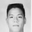

In [12]:
# show image
img_index = 12
image_bytes = images_bin[1990][img_index][1]
bytes_transformed = np.frombuffer(image_bytes, dtype=np.float32).reshape(3, 32, 32).transpose(1, 2, 0)
image_tensor = transforms.ToPILImage()(bytes_transformed)
display(image_tensor)

In [13]:
import numpy as np
# encode label into nparray: using the list[tuple[int, bytes]] create a np.array with the labels
def get_labeled_array_for_year(year: int) -> np.array:
    processed_images = []

    for label, image_bytes in images_bin[year]:
        # Convert bytes to numpy array and reshape
        image_array = np.frombuffer(image_bytes, dtype=np.float32).reshape(3, 32, 32).transpose(1, 2, 0)
        label_dimension = image_array.copy()
        label_dimension.fill(label)
        processed_images.append(np.stack([image_array, label_dimension]))

    # Stack all processed images into a single numpy array
    result_array = np.stack(processed_images)
    return result_array

In [14]:
get_labeled_array_for_year(1930)[8]

array([[[[0.9019608 , 0.9019608 , 0.9019608 ],
         [0.90588236, 0.90588236, 0.90588236],
         [0.91764706, 0.91764706, 0.91764706],
         ...,
         [0.2627451 , 0.2627451 , 0.2627451 ],
         [0.24313726, 0.24313726, 0.24313726],
         [0.16470589, 0.16470589, 0.16470589]],

        [[0.6039216 , 0.6039216 , 0.6039216 ],
         [0.5568628 , 0.5568628 , 0.5568628 ],
         [0.5176471 , 0.5176471 , 0.5176471 ],
         ...,
         [0.28627452, 0.28627452, 0.28627452],
         [0.2509804 , 0.2509804 , 0.2509804 ],
         [0.18431373, 0.18431373, 0.18431373]],

        [[0.11764706, 0.11764706, 0.11764706],
         [0.12156863, 0.12156863, 0.12156863],
         [0.13333334, 0.13333334, 0.13333334],
         ...,
         [0.28627452, 0.28627452, 0.28627452],
         [0.25490198, 0.25490198, 0.25490198],
         [0.19607843, 0.19607843, 0.19607843]],

        ...,

        [[0.34901962, 0.34901962, 0.34901962],
         [0.38431373, 0.38431373, 0.38431373]

# Supervised

In [15]:
tensors_per_year = {
    year: get_labeled_array_for_year(year)
    for year in range(1930, 2010)
}
# {ref: target: distance}
results: dict[int, dict[int, float]] = {}
for ref_year in range(1930, 2010):
    results[ref_year] = {}
    cd = MMDDrift(tensors_per_year[ref_year], backend='pytorch', p_val=.02, n_permutations=600)
    for target_year in range(1930, 2010):
        results[ref_year][target_year] = cd.predict(tensors_per_year[target_year][:])

No GPU detected, fall back on CPU.
No GPU detected, fall back on CPU.


KeyboardInterrupt: 

In [ ]:
results

In [ ]:
distances = {
    ref_year: {
        target_year: target_results["data"]["distance"]
        for target_year, target_results in ref_results.items()
    }
    for ref_year, ref_results in results.items()
}
distances[1930][2000]

In [ ]:
drift = {
    ref_year: {
        target_year: target_results["data"]["is_drift"]
        for target_year, target_results in ref_results.items()
    }
    for ref_year, ref_results in results.items()
}
drift[1930][2000]

In [ ]:
# outer keys := ref_year --> rows in matrix
df_distances = pd.DataFrame(distances).transpose().sort_index(axis=1).sort_index(axis=0)
df_drift = pd.DataFrame(drift).transpose().sort_index(axis=1).sort_index(axis=0)

In [ ]:
df_drift

In [ ]:
from plotly import graph_objects as go

fig = go.Figure(
    data=go.Heatmap(
        z=df_distances.values,
        x=df_distances.columns,
        y=df_distances.index,
        # colorscale="RdBu_r",
    ),
)

fig.update_layout(
    width=600,
    height=600,
    # "pipeline_id": "Pipeline",
    # "metric": "Metric",
    # "interval_center": "Evaluation time (interval center)",
)

# Show virtual modyn trigger walk
col = 0
shapes = []
for i in range(df_drift.shape[0]):
    target_year = 1930+i
    ref_year = 1930+col
    shapes += [dict(
        type="rect", x0=target_year-0.5, y0=ref_year-0.5, x1=target_year+0.5, y1=ref_year+0.5,
        line=dict(color="White", width=1.5),
    )]
    if drift[1930+col][1930+i]:
        shapes += [dict(
            type="line", x0=target_year+0.5, y0=ref_year+0.5, x1=target_year+0.5, y1=target_year-0.5,
            line=dict(color="White", width=1.5),
        )]
        col = i

fig.update_layout(shapes=shapes)
fig.show()

In [ ]:
from plotly import graph_objects as go

fig = go.Figure(
    data=go.Heatmap(
        z=df_drift.values,
        x=df_distances.columns,
        y=df_drift.index,
        colorscale="redor",
    ),
)

fig.update_layout(
    width=600,
    height=600,
)

# Show virtual modyn trigger walk
col = 0
shapes = []
for i in range(df_drift.shape[0]):
    target_year = 1930+i
    ref_year = 1930+col
    shapes += [dict(
        type="rect", x0=target_year-0.5, y0=ref_year-0.5, x1=target_year+0.5, y1=ref_year+0.5,
        line=dict(color="White", width=1.5),
    )]
    if drift[1930+col][1930+i]:
        shapes += [dict(
            type="line", x0=target_year+0.5, y0=ref_year+0.5, x1=target_year+0.5, y1=target_year-0.5,
            line=dict(color="White", width=1.5),
        )]
        col = i

fig.update_layout(shapes=shapes)
fig.show()

df = pd.DataFrame(distances).sort_index(axis=1).sort_index(axis=0)
print(df)
fig = px.imshow(df, labels=dict(x="X Axis", y="Y Axis", color="Distance"), x=df.columns, y=df.index)
fig.show()

# Simple image data (unsupervised)

In [ ]:
tensors_per_year = {
    year: np.stack([
        np.frombuffer(img, dtype=np.float32).reshape(3, 32, 32).transpose(1, 2, 0) for _, img in images_bin[year]
    ])
    for year in range(1930, 2010)
}

In [ ]:
cd = MMDDrift(tensors_per_year[1930], backend='pytorch', p_val=.05)

In [ ]:
cd.predict(tensors_per_year[1930])

In [ ]:
# {ref: target: distance}
results: dict[int, dict[int, float]] = {}
for ref_year in range(1930, 2010):
    results[ref_year] = {}
    cd = MMDDrift(tensors_per_year[ref_year], backend='pytorch', p_val=.05)
    for target_year in range(1930, 2010):
        results[ref_year][target_year] = cd.predict(tensors_per_year[target_year][:])

In [ ]:
distances = {
    ref_year: {
        target_year: target_results["data"]["distance"]
        for target_year, target_results in ref_results.items()
    }
    for ref_year, ref_results in results.items()
}
distances[1930][1933]

In [ ]:
df = pd.DataFrame(distances).sort_index(axis=1).sort_index(axis=0)
print(df)
fig = px.imshow(df, labels=dict(x="X Axis", y="Y Axis", color="Distance"), x=df.columns, y=df.index)
fig.show()

In [ ]:
from evidently import ColumnMapping
from evidently.metrics import EmbeddingsDriftMetric
from evidently.metrics.data_drift import embedding_drift_methods
from evidently.report import Report
import pandas as pd

column_mapping = ColumnMapping(embeddings={"data": reference_embeddings_df.columns})

metric = embedding_drift_methods.model(threshold=0.7)
metrics = [EmbeddingsDriftMetric("data", drift_method=metric)]

reference_embeddings_df = pd.DataFrame(data=images_bin, columns=["label", "image"])
current_embeddings_df = pd.DataFrame(data=images_bin, columns=["label", "image"])

report = Report(metrics=metrics)
report.run(
    reference_data=reference_embeddings_df,
    current_data=current_embeddings_df,
    column_mapping=column_mapping
)
result = report.as_dict()
result_print = [
    (x["result"]["drift_score"], x["result"]["method_name"], x["result"]["drift_detected"])
    for x in result["metrics"]
]

result["metrics"][0]["result"]["drift_detected"]

In [ ]:
def bytes_parser_function(data: bytes) -> torch.Tensor:
    return torch.from_numpy(np.frombuffer(data, dtype=np.float32)).reshape(1, 32, 32)

In [ ]:
file1 = Path("/Users/robinholzinger/robin/dev/eth/modyn/.debug.log/datasets/yearbook/test/2000.bin")

In [ ]:
file1_bytes = file1.read_bytes()

In [ ]:
record_size = 12288 + 4
label_size = 4

In [ ]:
num_items = len(file1_bytes) // record_size
len(file1_bytes) / record_size

In [ ]:
images_bin: list[tuple[int, bytes]] = []
for i in range(num_items):
    label = file1_bytes[i*record_size:i*record_size+label_size]
    # int from bytes
    image = file1_bytes[i*record_size+label_size:i*record_size+record_size]
    images_bin.append((int.from_bytes(label, byteorder='big'), image))



In [ ]:
len(images_bin[0][1])

In [ ]:
32*32*3

In [ ]:
len(images_bin[0][1]) / (32*32*3)

In [ ]:
import struct


# img_bytes = image1[4:4+12288]
img_bytes = images_bin[22][1]

# cast to float tensor (32, 32, 3)

img_parsed = np.frombuffer(img_bytes, dtype=np.float32).reshape(32, 32, 3)

In [ ]:
len(img_bytes) / 32 / 32

In [ ]:
img_parsed.shape

In [ ]:
tensor_to_PIL = transforms.ToPILImage()
image_tensor = tensor_to_PIL(img_parsed)
display(image_tensor)

In [ ]:
iimg = np.load("/Users/robinholzinger/robin/dev/eth/modyn/benchmark/wildtime_benchmarks/iimg.npy")

In [ ]:
# transform_image = bytes_parser_function(images_bin[0][1])
np.array(images_bin[0][1]).transpose(2, 0, 1)

In [ ]:
import io


image = Image.frombytes('RGB', (32, 32), np.array(images_bin[0][1]), 'raw')
display(image)

In [ ]:
tiimg = np.array(iimg.transpose(2, 0, 1))

In [ ]:
cd = MMDDrift(x_ref, backend='pytorch', p_val=.05)
preds = cd.predict(x)

In [ ]:
import pickle


pickle.dump()

In [ ]:
import os


ll = pickle.load(open("/Users/robinholzinger/robin/dev/eth/modyn/.debug.log/datasets/yearbook/yearbook.pkl", "rb"))

In [ ]:
ll[1940][0]["images"][0]
ll[1940][0]["images"][0].transpose(2, 0, 1)

In [ ]:
ll[1950][0]["images"][20].shape

In [ ]:
ll[1950][0]["images"][20].dtype

In [ ]:
xt = torch.FloatTensor(
    np.array(ll[1950][0]["images"][20].transpose(2, 0, 1))
)

In [ ]:
xt.dtype

In [ ]:
len(xt.numpy().tobytes())

In [ ]:

tensor_to_PIL = transforms.ToPILImage()
image_tensor = tensor_to_PIL(xt)
# image_tensor = tensor_to_PIL(ll[1950][0]["images"][20])
print(image_tensor.size)
display(image_tensor)